# Sentimental Model Using Yelp Reviews

## Libraries

In [34]:
import pandas as pd
import numpy as np
import json

from joblib import dump, load
import os

# Text cleaning
import re

# Machine learning
from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer)

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    f1_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
from scipy.stats import uniform, randint

from sklearn.dummy import DummyClassifier
import kagglehub


## Loading The Dataset

In [35]:
!pip install kagglehub --quiet

In [36]:
dataset_path = kagglehub.dataset_download("yelp-dataset/yelp-dataset")
print("Dataset downloaded to:", dataset_path)

Dataset downloaded to: C:\Users\saraa\.cache\kagglehub\datasets\yelp-dataset\yelp-dataset\versions\4


## Exploring The Dataset

In [37]:
print(os.listdir(dataset_path))

file_path = os.path.join(dataset_path, "yelp_academic_dataset_review.json")

data = []
with open(file_path, 'r', encoding='utf-8') as data_file:
    for i, line in enumerate(data_file):
        if i >= 400000:
            break
        data.append(json.loads(line))

review_df = pd.DataFrame(data)
print(f"Loaded {len(review_df)} reviews")

['Dataset_User_Agreement.pdf', 'yelp_academic_dataset_business.json', 'yelp_academic_dataset_checkin.json', 'yelp_academic_dataset_review.json', 'yelp_academic_dataset_tip.json', 'yelp_academic_dataset_user.json']
Loaded 400000 reviews


In [38]:
review_df.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,"I've taken a lot of spin classes over the years, and nothing compares to the classes at Body Cycle. From the nice, clean space and amazing bikes, to the welcoming and motivating instructors, every...",2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with ...",2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in a...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of upcoming patio/rooftop area which will be great on beautiful days like today. Cheese curds were very good and very filling. Really like that sandwiches ...,2017-01-14 20:54:15


In [39]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   review_id    400000 non-null  object 
 1   user_id      400000 non-null  object 
 2   business_id  400000 non-null  object 
 3   stars        400000 non-null  float64
 4   useful       400000 non-null  int64  
 5   funny        400000 non-null  int64  
 6   cool         400000 non-null  int64  
 7   text         400000 non-null  object 
 8   date         400000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 27.5+ MB


In [40]:
review_df.isnull().sum()

review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64

In [41]:
duplicate_reviews=review_df.duplicated(subset=["text"])
duplicate_reviews.sum()

558

In [42]:
review_df["stars"].value_counts()

stars
5.0    180424
4.0     96120
1.0     47928
3.0     43854
2.0     31674
Name: count, dtype: int64

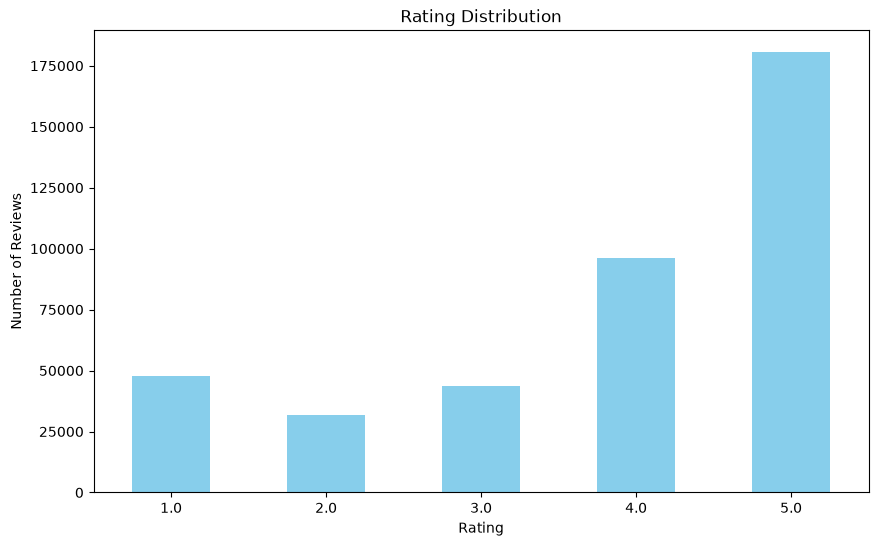

In [43]:
df_vis = review_df.copy()
df_vis['stars'] = df_vis['stars'].astype(str)  

plt.figure(figsize=(10, 6))
df_vis['stars'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()


In [44]:
pd.set_option("display.max_colwidth",200)

In [45]:
review_df["char_count"] = review_df["text"].apply(len)
review_df["word_count"] = review_df["text"].apply(lambda x: len(x.split()))

In [46]:
review_df.groupby("stars")[["char_count", "word_count"]].mean()

,char_count,word_count
stars,,
1.0,687.994158,129.119513
2.0,702.103145,130.694197
3.0,654.006111,121.359169
4.0,568.413233,104.491906
5.0,461.948926,84.331796


The Dataset is imbalanced with 70% being 4-5 stars and 30% being 3-4 stars, negative reviews usually have a higher word and character count. The dataset has no null values but does contain duplicates.

## Preprocessing

In [47]:
#renaming columns we will use
review_df = review_df.rename(columns={'text': 'review'})
review_df.head(0)

,review_id,user_id,business_id,stars,useful,funny,cool,review,date,char_count,word_count


In [48]:
review_cleaned_df = review_df[['review','stars']].copy()
review_cleaned_df.head()

,review,stars
0,"If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in...",3.0
1,"I've taken a lot of spin classes over the years, and nothing compares to the classes at Body Cycle. From the nice, clean space and amazing bikes, to the welcoming and motivating instructors, every...",5.0
2,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with ...",3.0
3,"Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in a...",5.0
4,Cute interior and owner (?) gave us tour of upcoming patio/rooftop area which will be great on beautiful days like today. Cheese curds were very good and very filling. Really like that sandwiches ...,4.0


In [49]:
review_cleaned_df = review_cleaned_df.drop_duplicates(subset=["review"])

In [50]:
review_cleaned_df = review_cleaned_df[review_cleaned_df["stars"]!=3]

In [51]:
review_cleaned_df['rating'] = review_cleaned_df['stars'].map({
    1.0:0,
    2.0:0,
    4.0:1,
    5.0:1
})
review_cleaned_df['rating']

1         1
3         1
4         1
5         0
6         1
         ..
399995    0
399996    1
399997    1
399998    1
399999    0
Name: rating, Length: 355627, dtype: int64

In [52]:
review_cleaned_df['rating'].value_counts()

rating
1    276149
0     79478
Name: count, dtype: int64

In [53]:
review_cleaned_df['rating'].value_counts(normalize=True)

rating
1    0.776513
0    0.223487
Name: proportion, dtype: float64

In [54]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " URL ", text)
    text = re.sub(r"<.*?>", " ", text)
    
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "can not", text)
    text = re.sub(r"n't", " not", text) 
    
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    
    text = re.sub(r"[^a-z0-9\s!?]", " ", text) 
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [55]:
review_cleaned_df["clean_review"] = review_cleaned_df["review"].apply(lambda x: clean_text(x))


In [56]:
review_cleaned_df[["review","clean_review"]].head(5)

,review,clean_review
1,"I've taken a lot of spin classes over the years, and nothing compares to the classes at Body Cycle. From the nice, clean space and amazing bikes, to the welcoming and motivating instructors, every...",i ve taken a lot of spin classes over the years and nothing compares to the classes at body cycle from the nice clean space and amazing bikes to the welcoming and motivating instructors every clas...
3,"Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in a...",wow! yummy different delicious our favorite is the lamb curry and korma with 10 different kinds of naan!! do not let the outside deter you because we almost changed our minds go in and try somethi...
4,Cute interior and owner (?) gave us tour of upcoming patio/rooftop area which will be great on beautiful days like today. Cheese curds were very good and very filling. Really like that sandwiches ...,cute interior and owner ? gave us tour of upcoming patio rooftop area which will be great on beautiful days like today cheese curds were very good and very filling really like that sandwiches come...
5,I am a long term frequent customer of this establishment. I just went in to order take out (3 apps) and was told they're too busy to do it. Really? The place is maybe half full at best. Does your ...,i am a long term frequent customer of this establishment i just went in to order take out 3 apps and was told they re too busy to do it really? the place is maybe half full at best does your dick ...
6,Loved this tour! I grabbed a groupon and the price was great. It was the perfect way to explore New Orleans for someone who'd never been there before and didn't know a lot about the history of the...,loved this tour! i grabbed a groupon and the price was great it was the perfect way to explore new orleans for someone who d never been there before and did not know a lot about the history of the...


We converted the original ratings into a binary classification problem, where 4‑5 stars represent positive reviews and 1‑3 stars represent negative reviews. This decision simplifies the task and focuses on distinguishing satisfied from dissatisfied customers.

The preprocessing pipeline included:

1. Dropping duplicate entries
2. Cleaning the review text (removing punctuation, stopwords, and other noise)
3. Renaming columns for better readability
4. Mapping the stars column to a new feature called rating

For our model, we used only the clean_review and rating columns.



## Readying the data for training/testing

In [57]:
x=review_cleaned_df["clean_review"]
y=review_cleaned_df["rating"]

In [58]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state = 42, stratify = y)

In [59]:
train_dist = y_train.value_counts(normalize=True) * 100
test_dist = y_test.value_counts(normalize=True) * 100

print("y_train distribution :")
print(train_dist.round(2))

print("\ny_test distribution:")
print(test_dist.round(2))


y_train distribution :
rating
1    77.65
0    22.35
Name: proportion, dtype: float64

y_test distribution:
rating
1    77.65
0    22.35
Name: proportion, dtype: float64


## Metric Funtion

In [60]:
def evaluation_metrics(model, model_name, x_train, y_train, x_test, y_test, model_fit=True):
    if model_fit:
        model.fit(x_train, y_train)

    predict = model.predict(x_test)
    return {
        "Model": model_name,
        "accuracy": round(accuracy_score(y_test, predict),3),
        "precision": round(precision_score(y_test, predict, average='weighted',zero_division=1),3),
        "recall": round(recall_score(y_test, predict, average='weighted',zero_division=1),3),
        "f1": round(f1_score(y_test, predict, average='weighted',zero_division=1),3)
    }

## Creating the Baseline Model

In [61]:
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_clf.fit(np.zeros((len(x_train), 1)),y_train)

y_pred_dummy = dummy_clf.predict(np.zeros((len(x_test), 1)))

dummy_result = evaluation_metrics(dummy_clf, "Dummy Baseline", x_train, y_train, x_test, y_test, model_fit=False)

In [62]:
dummy_result

{'Model': 'Dummy Baseline',
 'accuracy': 0.777,
 'precision': 0.826,
 'recall': 0.777,
 'f1': 0.679}

In [63]:
model = Pipeline([
    ("TF-IDF", TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=2)),
    ("Classifier", LogisticRegression(max_iter=1000, random_state=42))
])
baseline_logistic_result = evaluation_metrics(model, "Logistic Baseline (ngram_range=(1, 2), max_features=5000, min_df=2)", x_train, y_train, x_test, y_test)

In [64]:
baseline_logistic_result

{'Model': 'Logistic Baseline (ngram_range=(1, 2), max_features=5000, min_df=2)',
 'accuracy': 0.962,
 'precision': 0.962,
 'recall': 0.962,
 'f1': 0.962}

## Fine Tunning a Model

In [65]:
model_space = Pipeline([
    ("TF-IDF", TfidfVectorizer()),
    ("Classifier", LogisticRegression(max_iter=1000, random_state = 42))
])


In [66]:
param_dist = {
    'TF-IDF__max_features': [5000, 10000, 15000, 20000],
    'TF-IDF__ngram_range': [(1,1), (1,2), (1,3)],
    'TF-IDF__min_df': [1, 3, 5],       
    'Classifier__C': [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
}

random_search = RandomizedSearchCV(
    model_space,            
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=10
)

random_search.fit(x_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('TF-IDF', TfidfVectorizer()),
                                             ('Classifier',
                                              LogisticRegression(max_iter=1000,
                                                                 random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'Classifier__C': [0.01, 0.05, 0.1, 0.5,
                                                          1.0, 2.0, 5.0],
                                        'TF-IDF__max_features': [5000, 10000,
                                                                 15000, 20000],
                                        'TF-IDF__min_df': [1, 3, 5],
                                        'TF-IDF__ngram_range': [(1, 1), (1, 2),
                                                                (1, 3)]},
                   random_state=42, scoring='f1', verbose=10)

In [67]:
print("Best params:", random_search.best_params_)
print("Best CV F1 score:", random_search.best_score_)

Best params: {'TF-IDF__ngram_range': (1, 2), 'TF-IDF__min_df': 1, 'TF-IDF__max_features': 15000, 'Classifier__C': 5.0}
Best CV F1 score: 0.9789433039108051


In [68]:
best_model = Pipeline([
    ("TF-IDF", TfidfVectorizer(ngram_range=(1, 2), max_features=15000, min_df=1)),
    ("Classifier", LogisticRegression(max_iter=1000, random_state=42, C=5))
])

In [69]:
best_model_result = evaluation_metrics(best_model, "Fine Tunned Logistic Regression Model", x_train, y_train, x_test, y_test) 

## Plotting The Accuracy and Validation Curve

In [70]:
results = pd.DataFrame(random_search.cv_results_)

results_sorted = results.sort_values('mean_test_score', ascending=False)

print("Top 5 combinations:")
print(results_sorted[['mean_test_score', 'std_test_score', 'params']].head(5))


Top 5 combinations:
    mean_test_score  std_test_score  \
7          0.978943        0.000240   
6          0.978129        0.000353   
12         0.977684        0.000239   
3          0.977409        0.000400   
11         0.975224        0.000195   

                                                                                                       params  
7   {'TF-IDF__ngram_range': (1, 2), 'TF-IDF__min_df': 1, 'TF-IDF__max_features': 15000, 'Classifier__C': 5.0}  
6   {'TF-IDF__ngram_range': (1, 2), 'TF-IDF__min_df': 1, 'TF-IDF__max_features': 15000, 'Classifier__C': 2.0}  
12  {'TF-IDF__ngram_range': (1, 2), 'TF-IDF__min_df': 1, 'TF-IDF__max_features': 10000, 'Classifier__C': 5.0}  
3   {'TF-IDF__ngram_range': (1, 2), 'TF-IDF__min_df': 1, 'TF-IDF__max_features': 20000, 'Classifier__C': 1.0}  
11   {'TF-IDF__ngram_range': (1, 3), 'TF-IDF__min_df': 1, 'TF-IDF__max_features': 5000, 'Classifier__C': 5.0}  


## Comparision 

In [71]:
comparison_df = pd.DataFrame([dummy_result,baseline_logistic_result,best_model_result])

In [72]:
comparison_df.sort_values(by='f1', ascending=False)

,Model,accuracy,precision,recall,f1
2,Fine Tunned Logistic Regression Model,0.969,0.968,0.969,0.968
1,"Logistic Baseline (ngram_range=(1, 2), max_features=5000, min_df=2)",0.962,0.962,0.962,0.962
0,Dummy Baseline,0.777,0.826,0.777,0.679


In [73]:
predict = best_model.predict(x_test)

In [74]:
baseline_logistic_predict = model.predict(x_test)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.90      0.91     15896
    Positive       0.97      0.98      0.98     55230

    accuracy                           0.96     71126
   macro avg       0.95      0.94      0.94     71126
weighted avg       0.96      0.96      0.96     71126



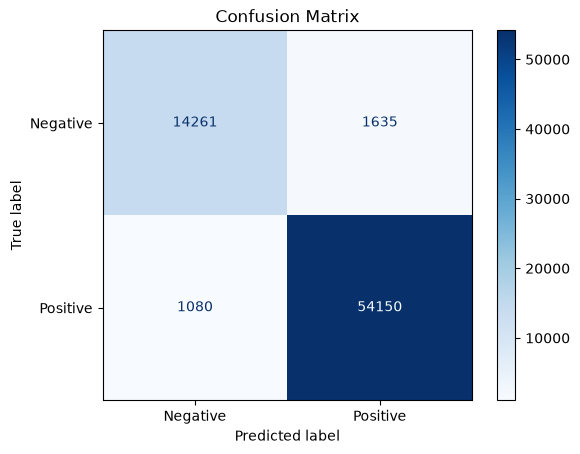

In [76]:
print("Classification Report:")
print(classification_report(y_test, baseline_logistic_predict, target_names=['Negative', 'Positive'],zero_division=1))

cm_base = confusion_matrix(y_test, baseline_logistic_predict)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix')
plt.show()


Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.92      0.93     15896
    Positive       0.98      0.98      0.98     55230

    accuracy                           0.97     71126
   macro avg       0.96      0.95      0.95     71126
weighted avg       0.97      0.97      0.97     71126



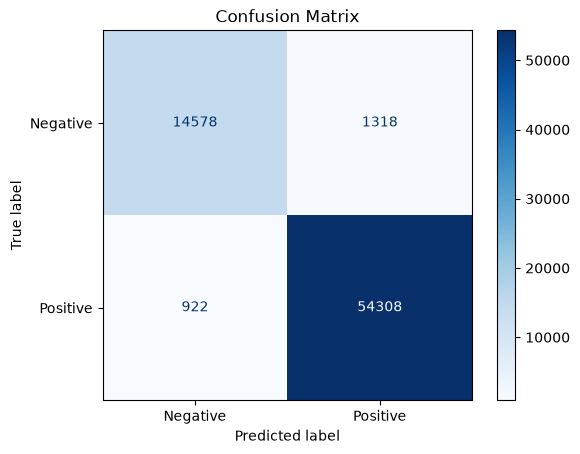

In [77]:
# Write your code here
print("Classification Report:")
print(classification_report(y_test, predict, target_names=['Negative', 'Positive'],zero_division=1))

cm = confusion_matrix(y_test, predict)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix')
plt.show()


## Most and Least Used words of each area

In [78]:
tfidf = best_model.named_steps["TF-IDF"]
feature_names = np.array(tfidf.get_feature_names_out())
log_reg = best_model.named_steps["Classifier"]
coefficients = log_reg.coef_[0] 
classes = log_reg.classes_
top_n = 10

top_positive_idx = np.argsort(coefficients)[-top_n:][::-1]
top_negative_idx = np.argsort(coefficients)[:top_n]

print(f"Top {top_n} words/bigrams INCREASING likelihood of '{classes[1]}' (Positive):")
for idx in top_positive_idx:
    print(f"  {feature_names[idx]:<25} {coefficients[idx]:.4f}")

print(f"\nTop {top_n} words/bigrams INCREASING likelihood of '{classes[0]}' (Negative):")
for idx in top_negative_idx:
    print(f"  {feature_names[idx]:<25} {coefficients[idx]:.4f}")

Top 10 words/bigrams INCREASING likelihood of '1' (Positive):
  delicious                 22.0855
  amazing                   20.9674
  great                     17.4048
  excellent                 16.5763
  awesome                   15.7142
  perfect                   15.5403
  fantastic                 13.0732
  best                      11.3442
  wonderful                 11.2593
  be disappointed           10.8389

Top 10 words/bigrams INCREASING likelihood of '0' (Negative):
  mediocre                  -14.9029
  not worth                 -14.9021
  worst                     -14.8563
  bland                     -14.3881
  two stars                 -14.2476
  disappointing             -14.0601
  meh                       -13.2794
  horrible                  -13.2418
  not good                  -12.7515
  not                       -12.7367


## Final Decision + Downloading the Model

This Model had the highest F1/Precision/Recall Score on unseen data, however it does have 15k words which is 10k more words than the 2nd best containing only 5k words.

In [ ]:
dump(best_model, 'sentiment_model_best.joblib') 
